In [1]:
import h5py

In [3]:
mesh_2_file = h5py.File('/scratch/saporito/Frag3D/mesh_1_L_over_100_brittle/data.h5', 'r')

In [4]:
sorted_keys_m2 = sorted(mesh_2_file.keys(), key=lambda x: int(x.split('_')[-1]))
print("Sorted keys in mesh_2_file:", sorted_keys_m2)

Sorted keys in mesh_2_file: ['step_0', 'step_16', 'step_32', 'step_48', 'step_64', 'step_80', 'step_96', 'step_112', 'step_128', 'step_144', 'step_160', 'step_176', 'step_192', 'step_208', 'step_224', 'step_240', 'step_256', 'step_272', 'step_288', 'step_304', 'step_320', 'step_336', 'step_352', 'step_368', 'step_384', 'step_400', 'step_416', 'step_432', 'step_448', 'step_464', 'step_480', 'step_496', 'step_512', 'step_528', 'step_544', 'step_560', 'step_576', 'step_592', 'step_608', 'step_624', 'step_640', 'step_656', 'step_672', 'step_688', 'step_704', 'step_720', 'step_736', 'step_752', 'step_768', 'step_784', 'step_800', 'step_816', 'step_832', 'step_848', 'step_864', 'step_880', 'step_896', 'step_912', 'step_928', 'step_944', 'step_960', 'step_976', 'step_992', 'step_1008', 'step_1024', 'step_1040', 'step_1056', 'step_1072', 'step_1088', 'step_1104', 'step_1120', 'step_1136', 'step_1152', 'step_1168', 'step_1184', 'step_1200', 'step_1216', 'step_1232', 'step_1248', 'step_1264', 's

In [5]:
final_step_mesh_2 = mesh_2_file['step_16866']

In [6]:
print(final_step_mesh_2.attrs.keys())

<KeysViewHDF5 ['econ', 'edis', 'ekin', 'epot', 'erev', 'nb_fragments', 'time', 'total_energy', 'work']>


In [7]:
final_time = final_step_mesh_2.attrs['time']
print(final_time)

3.9998039295056235e-05


In [8]:
import numpy as np
import matplotlib.pyplot as plt

In [9]:
# Savding variation of ['econ', 'edis', 'ekin', 'epot', 'erev', 'nb_fragments', 'time', 'total_energy', 'work']
# wrt their value in step_0 at each step
econ = []
edis = []
ekin = []
epot = []
erev = []
nb_fragments = []
total_energy = []
for step in sorted_keys_m2:
    step_data = mesh_2_file[step]
    econ.append(step_data.attrs['econ'])
    edis.append(step_data.attrs['edis'])
    ekin.append(step_data.attrs['ekin'])
    epot.append(step_data.attrs['epot'])
    erev.append(step_data.attrs['erev'])
    nb_fragments.append(step_data.attrs['nb_fragments'])
    total_energy.append(step_data.attrs['total_energy'])
steps = np.array(sorted_keys_m2)
econ = np.array(econ)
edis = np.array(edis)
ekin = np.array(ekin)
epot = np.array(epot)
erev = np.array(erev)
nb_fragments = np.array(nb_fragments)
total_energy = np.array(total_energy)

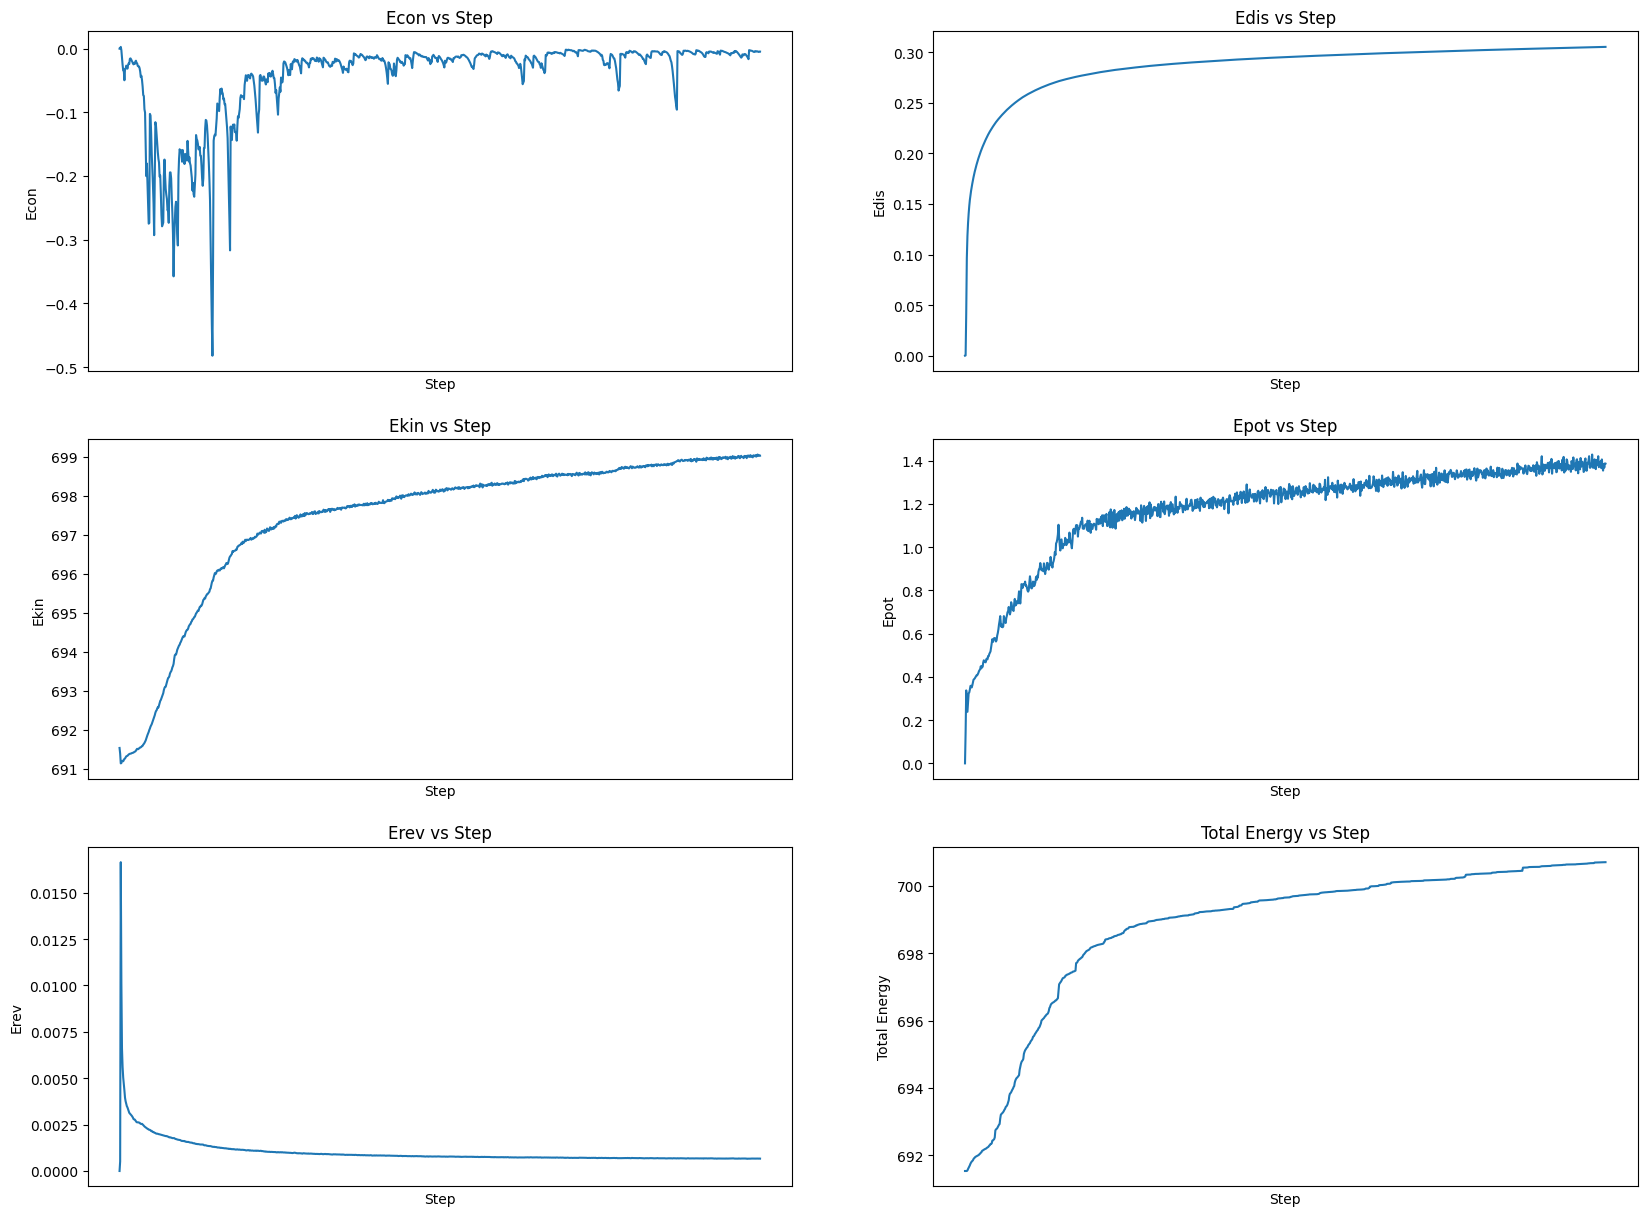

In [10]:
# Plotting the variation of these quantities over time steps
plt.figure(figsize=(20, 15))
plt.subplot(3, 2, 1)
plt.plot(steps, econ, label='Econ')
plt.xticks([])
plt.xlabel('Step')
plt.ylabel('Econ')
plt.title('Econ vs Step')
plt.subplot(3, 2, 2)
plt.plot(steps, edis, label='Edis')
plt.xticks([])
plt.xlabel('Step')
plt.ylabel('Edis')
plt.title('Edis vs Step')
plt.subplot(3, 2, 3)
plt.plot(steps, ekin, label='Ekin')
plt.xticks([])
plt.xlabel('Step')
plt.ylabel('Ekin')
plt.title('Ekin vs Step')
plt.subplot(3, 2, 4)
plt.plot(steps, epot, label='Epot')
plt.xticks([])
plt.xlabel('Step')
plt.ylabel('Epot')
plt.title('Epot vs Step')
plt.subplot(3, 2, 5)
plt.plot(steps, erev, label='Erev')
plt.xticks([])
plt.xlabel('Step')
plt.ylabel('Erev')
plt.title('Erev vs Step')
plt.subplot(3, 2, 6)
plt.plot(steps, total_energy, label='Total Energy')
plt.xticks([])
plt.xlabel('Step')
plt.ylabel('Total Energy')
plt.title('Total Energy vs Step')
plt.show()

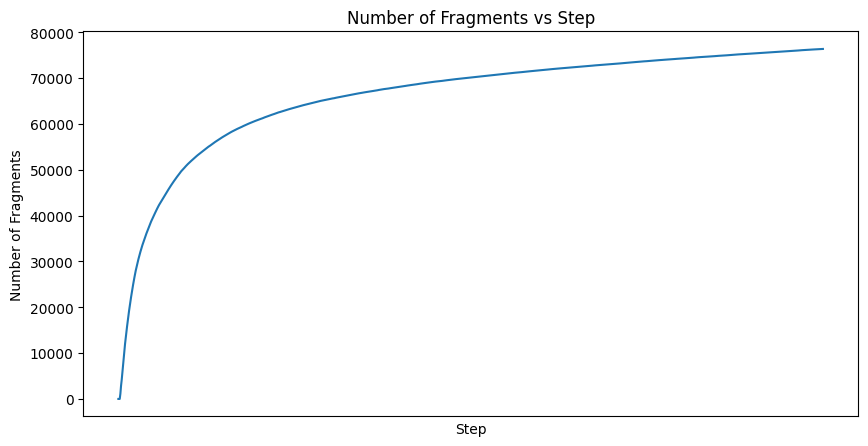

In [11]:
# PLotting number of fragments over time steps
plt.figure(figsize=(10, 5))
plt.plot(steps, nb_fragments, label='Number of Fragments')
plt.xticks([])
plt.xlabel('Step')
plt.ylabel('Number of Fragments')
plt.title('Number of Fragments vs Step')
plt.show()

In [12]:
final_masses = final_step_mesh_2['fragment_mass'][:]
final_velocities = final_step_mesh_2['fragment_velocity'][:]
final_com = final_step_mesh_2['fragment_COM'][:]
print(final_masses)
print(final_velocities)
print(final_com)

[2.34758323e-07 2.34758323e-07 2.34758323e-07 ... 5.02757944e-08
 4.87144949e-08 4.87144949e-08]
[[  2.88798685  -0.78583447 494.84585589]
 [ -3.35588607  -0.78532002 153.67247343]
 [ -4.67543262   4.21865484 116.28557595]
 ...
 [ -4.19321048   4.89716217  59.25886303]
 [ -4.39841779   4.91430331  40.73340338]
 [ -2.18864845  -0.92093825  49.31736229]]
[[-0.00667664 -0.00979739 -0.0005667 ]
 [ 0.01829805 -0.00655128 -0.00061456]
 [ 0.01924039 -0.00776711 -0.00072538]
 ...
 [ 0.02312757 -0.00761717 -0.00030399]
 [ 0.02306317 -0.0094686  -0.00070412]
 [ 0.02362254 -0.0075821  -0.00077567]]


In [13]:
# print mean, min, max, std of masses and velocity magnitudes
mean_mass = np.mean(final_masses)
min_mass = np.min(final_masses)
max_mass = np.max(final_masses)
std_mass = np.std(final_masses)
velocity_magnitudes = np.linalg.norm(final_velocities, axis=1)
mean_velocity = np.mean(velocity_magnitudes)
min_velocity = np.min(velocity_magnitudes)
max_velocity = np.max(velocity_magnitudes)
std_velocity = np.std(velocity_magnitudes)
print(f"Masses - Mean: {mean_mass}, Min: {min_mass}, Max: {max_mass}, Std: {std_mass}")
print(f"Velocity Magnitudes - Mean: {mean_velocity}, Min: {min_velocity}, Max: {max_velocity}, Std: {std_velocity}")

Masses - Mean: 2.211312163572041e-07, Min: 1.2823453690474632e-08, Max: 0.00015276832382734576, Std: 2.496664579152197e-06
Velocity Magnitudes - Mean: 365.896670806736, Min: 3.3827453247339903, Max: 1315.2021885512027, Std: 254.75821156528434


In [24]:
import pyvista as pv

2026-04-20 11:51:15.894 (   9.629s) [    7FD13FC29740]vtkXOpenGLRenderWindow.:1460  WARN| bad X server connection. DISPLAY=
/tmp/ipykernel_1752586/790276196.py:28: UserWarning: Failed to use notebook backend: 

No module named 'trame'

Falling back to a static output.
  plotter.show()


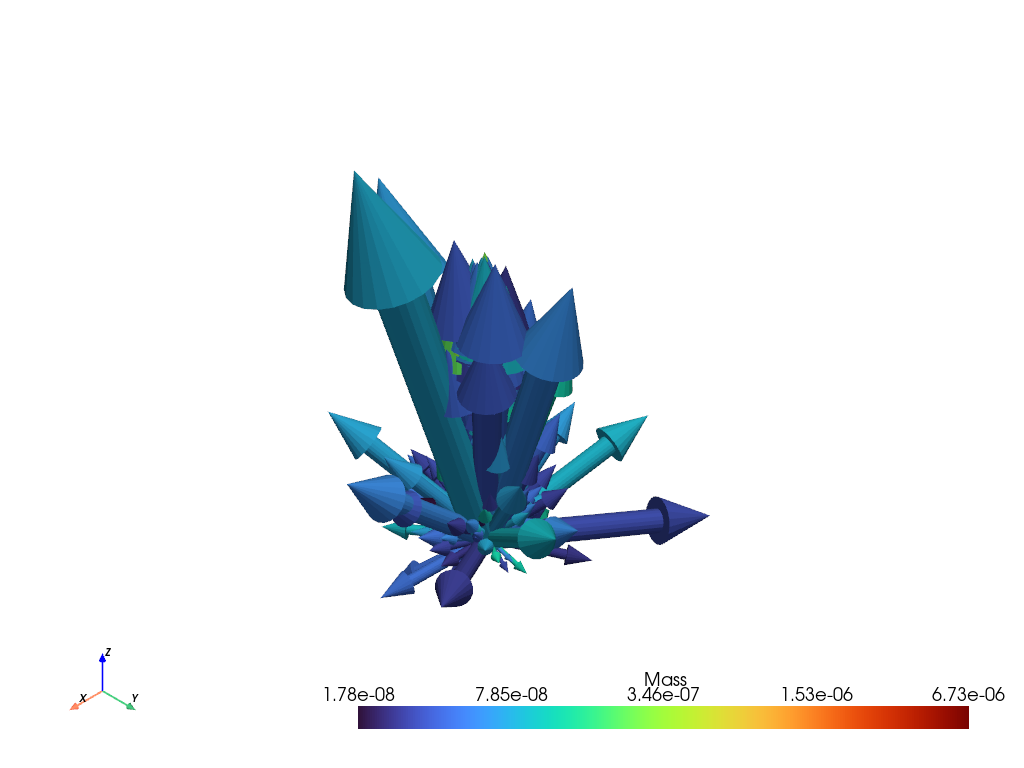

In [14]:
point_cloud = pv.PolyData(final_com)
point_cloud["velocity"] = final_velocities
point_cloud["mass"] = final_masses

# We use the 'velocity' for orientation and magnitude scaling
glyphs = point_cloud.glyph(
    orient="velocity",
    scale=True,  # This scales the arrow length by velocity magnitude
    factor=0.1,
    geom=pv.Arrow(
        tip_radius=0.1,   # Fixed values here
        tip_length=0.25,
        shaft_radius=0.05 
    ),
)

plotter = pv.Plotter()
plotter.add_mesh(
    glyphs,
    scalars="mass",
    cmap="turbo",
    show_scalar_bar=True,
    scalar_bar_args={"title": "Mass"},
    clim=[min_mass, max_mass],
    log_scale=True,
)
plotter.add_axes()
plotter.show()